/home/vklimkov/miniconda3/envs/vllm/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


torch.Size([292800]) torch.float32


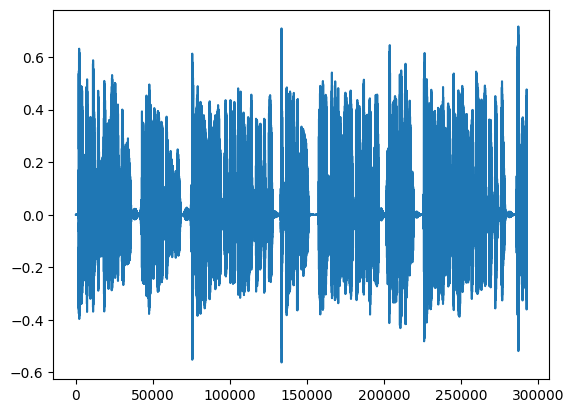

In [1]:
import soundfile
import torch
import matplotlib.pyplot as plt


y, sr = soundfile.read("/home/vklimkov/workspace/vllm/vllm/fastconformer_test_data/sample.wav", dtype="float32", always_2d=True)
assert sr == 16000
test_audio = torch.from_numpy(y.T).contiguous().cuda()[0]  # shape [samples]
# we have x1280 downsampling, so if we want 20 frames, we need:
#samples_num = 90 * 160 * 8
#print(test_audio.shape, test_audio.dtype)
#test_audio = test_audio[:samples_num]
print(test_audio.shape, test_audio.dtype)
plt.plot(test_audio.cpu().numpy())
plt.show()

In [2]:
import torch

from vllm.engine.arg_utils import AsyncEngineArgs
from vllm.v1.engine.async_llm import AsyncLLM
from vllm.sampling_params import SamplingParams

engine_args = AsyncEngineArgs(
    model="./fastconformer_model/",
    max_model_len=1024,
    gpu_memory_utilization=0.8,
    block_size=128,
    skip_tokenizer_init=True,
    enable_prefix_caching=False,
    dtype="float32",
    #enforce_eager=True,
    #load_format="dummy",
)
engine = AsyncLLM.from_engine_args(engine_args)
sampling_params = SamplingParams(max_tokens=4096, skip_sampling=True)


# reshape audio to [target_t, factor]
audio = test_audio.cpu()
# run preemphasis here
audio = torch.cat(
    (audio[0:1], audio[1:] - 0.97 * audio[:-1]), dim=0
)
print(audio.shape)

request_id = "1"
prompt_len = 1
i = 0
inputs = {
    # dummy tokens
    "prompt_token_ids": [0] * prompt_len,
    # actual inpust to the model in prefill stage
    "custom_inputs": {
        "audio": audio[i * 1280:(i+prompt_len) * 1280].view(prompt_len, 1280)  # 1 x 8*160
    }
}
i += prompt_len
outputs = []
async for output in engine.generate(inputs, sampling_params=sampling_params, request_id=request_id):
    acoustic_emb = output.outputs[0].custom_outputs["acoustic_emb"].clone()
    outputs.append(acoustic_emb)
    if i >= audio.shape[0] // 1280:
        break
    # prepare the next one
    inputs = {"audio": audio[i * 1280:(i+1) * 1280].unsqueeze(0)}
    i += 1
    await engine.append_request(request_id=request_id, custom_inputs=inputs)

pred = torch.cat(outputs, dim=0).numpy()
print(pred.shape)


INFO 01-23 11:45:36 [__init__.py:224] Automatically detected platform cuda.


/home/vklimkov/miniconda3/envs/vllm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO 01-23 11:45:37 [model.py:655] Resolved architecture: FastConformerCTC


`torch_dtype` is deprecated! Use `dtype` instead!


ERROR 01-23 11:45:37 [config.py:298] Error retrieving safetensors: Repo id must be in the form 'repo_name' or 'namespace/repo_name': './fastconformer_model/'. Use `repo_type` argument if needed., retrying 1 of 2
ERROR 01-23 11:45:39 [config.py:296] Error retrieving safetensors: Repo id must be in the form 'repo_name' or 'namespace/repo_name': './fastconformer_model/'. Use `repo_type` argument if needed.
INFO 01-23 11:45:39 [model.py:1731] Using max model len 1024


...

[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
[Gloo] Rank 0 is connected to 0 peer ranks. Expected number of connected peer ranks is : 0
(EngineCore_DP0 pid=653714) INFO 01-23 11:45:42 [parallel_state.py:1231] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, TP rank 0, EP rank 0
(EngineCore_DP0 pid=653714) INFO 01-23 11:45:42 [topk_topp_sampler.py:59] Using FlashInfer for top-p & top-k sampling.
(EngineCore_DP0 pid=653714) INFO 01-23 11:45:42 [gpu_model_runner.py:3014] Starting to load model ./fastconformer_model/...
(EngineCore_DP0 pid=653714) INFO 01-23 11:45:42 [gpu_mode

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]
Loading safetensors checkpoint shards: 100% Completed | 1/1 [00:00<00:00, 201.39it/s]
(EngineCore_DP0 pid=653714) 


(EngineCore_DP0 pid=653714) [load_weights] Loaded 624 tensors.
(EngineCore_DP0 pid=653714) [load_weights] Model params with NO checkpoint match (15 shown first 40):
(EngineCore_DP0 pid=653714)   - preprocessor.mel_spec.fb : shape (257, 128)
(EngineCore_DP0 pid=653714)   - preprocessor.mel_spec.wcos : shape (257, 512)
(EngineCore_DP0 pid=653714)   - preprocessor.mel_spec.wsin : shape (257, 512)
(EngineCore_DP0 pid=653714)   - preprocessor.pre_encode.conv.0.conv_bias : shape (256,)
(EngineCore_DP0 pid=653714)   - preprocessor.pre_encode.conv.0.conv_weight : shape (3, 3, 256)
(EngineCore_DP0 pid=653714)   - preprocessor.pre_encode.conv.2.conv_bias : shape (256,)
(EngineCore_DP0 pid=653714)   - preprocessor.pre_encode.conv.2.conv_weight : shape (3, 3, 256)
(EngineCore_DP0 pid=653714)   - preprocessor.pre_encode.conv.3.bias : shape (256,)
(EngineCore_DP0 pid=653714)   - preprocessor.pre_encode.conv.3.weight : shape (256, 256)
(EngineCore_DP0 pid=653714)   - preprocessor.pre_encode.conv.5.co

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 35/35 [00:00<00:00, 42.83it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 19/19 [00:19<00:00,  1.03s/it]


(EngineCore_DP0 pid=653714) INFO 01-23 11:46:06 [gpu_model_runner.py:3974] Graph capturing finished in 21 secs, took 0.81 GiB
(EngineCore_DP0 pid=653714) INFO 01-23 11:46:06 [core.py:237] init engine (profile, create kv cache, warmup model) took 23.01 seconds
(EngineCore_DP0 pid=653714) INFO 01-23 11:46:06 [gc_utils.py:40] GC Debug Config. enabled:False,top_objects:-1
INFO 01-23 11:46:06 [loggers.py:148] Engine 000: vllm cache_config_info with initialization after num_gpu_blocks is: 1186
torch.Size([292800])
WARNING 01-23 11:46:06 [async_llm.py:283] Processor has been moved under OpenAIServing and will be removed from AsyncLLM in v0.13.
WARNING 01-23 11:46:06 [preprocess.py:81] Using None for EOS token id because tokenizer is not initialized
(228, 1024)


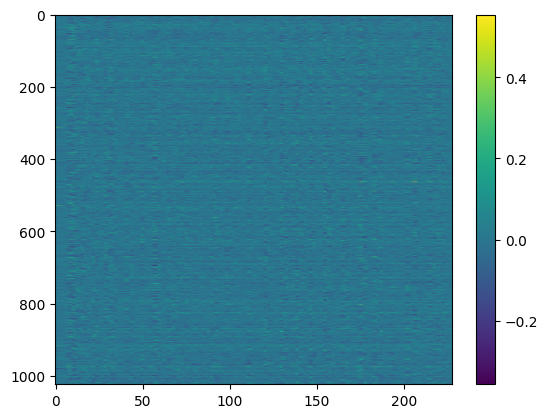

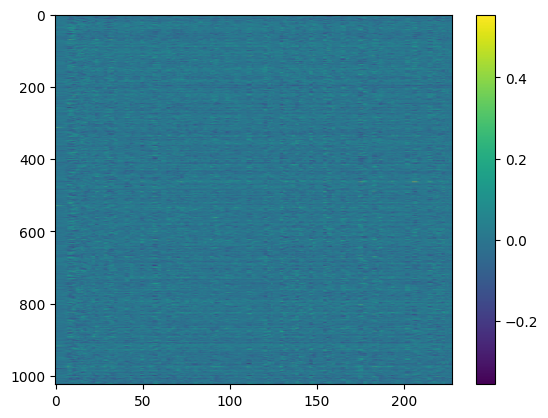

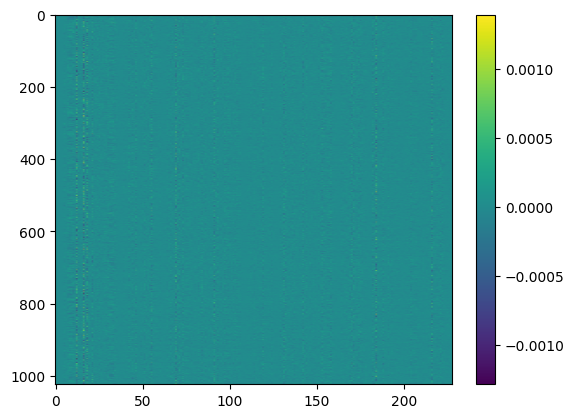

0.042586226


In [ ]:
import numpy as np
arr = np.load("fastconformer_test_data/nemo_outputs_compact.npy").T
plt.imshow(pred.T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(arr.T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(pred.T - arr.T, aspect="auto")
plt.colorbar()
plt.show()

print(np.linalg.norm(pred - arr))

In [ ]:
arr = torch.load("fastconformer_test_data/mel.pt").cpu().numpy()[:mel.shape[0]]
print(arr.shape)
print(mel.shape)
plt.imshow(mel.T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(arr.T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(mel.T - arr.T, aspect="auto")
plt.colorbar()
plt.show()

In [ ]:
arr = torch.load("fastconformer_test_data/inputs.pt").detach().cpu().numpy()
print(arr.shape)
print(subsampling.shape)
plt.imshow(subsampling.T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(arr.T, aspect="auto")
plt.colorbar()
plt.show()

plt.imshow(subsampling.T - arr.T, aspect="auto")
plt.colorbar()
plt.show()

In [ ]:
# load safetensors

import safetensors.torch

model = safetensors.torch.load_file("fastconformer_model/model.safetensors")
print(model["encoder.pre_encode.out.weight"].shape)
#print([x for x in model.keys() if "pre_encode" in x])


model = safetensors.torch.load_file("fastconformer_model/model.safetensors.old")
print(model["encoder.pre_encode.out.weight"].shape)
# print([x for x in model.keys() if "pre_encode" in x])